Fraud detection projects are most common now-a-days and very often, we come across different solutions online. They mostly deal with balancing the data first and then applying various supervised algorithms since the class labels are already available. However, in reality, most of the business data come without class labels and ***unsupervised algorithms play a big role in detecting anomalies***. So, I tried to do this work differently. I did not use balancing data, rather I tried to use the algorithms specially meant for solving anomaly detection problems. Also, I explored both unsupervised and supervised forms of the anomaly detection algorithms. 

**Key take away from this notebook:**
* Finding similar pattern in transactions using Cosine Similarity
* Visualizing frauds in 3D using PCA
* Visualizing frauds in 3D using t-SNE
* **Alrogithm 1A:** Isolated Forest in Unsupervised Sense (without labels)
* **Algorithm 1B:** Isolated Forest with a flavour of Supervised Learning (with labels)
* **Alrogithm 2A:** Local Outlier Factors in Unsupervised Sense (without labels)
* **Algorithm 2B:** Local Outlier Factors with a flavour of Supervised Learning (with labels)
* **Alrogithm 3A:** Elliptic Envelope in Unsupervised Sense (without labels)
* **Algorithm 3B:** Elliptic Envelope with a flavour of Supervised Learning (with labels)
* **Alrogithm 4A:** One-Class SVM in Unsupervised Sense (without labels)
* **Algorithm 4B:** One-Class SVM with a flavour of Supervised Learning (with labels)
* Self-Organized Maps to Detect Frauds

# Importing Data:

In [1]:
import pandas as pd
data = pd.read_csv('../input/creditcardfraud/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
data["Class"].value_counts()

0    284315
1       492
Name: Class, dtype: int64

A distribution of 284315 non-fraud and 492 fraud labels indicate a highly imbalanced data set.

In [4]:
import warnings
warnings.filterwarnings("ignore")

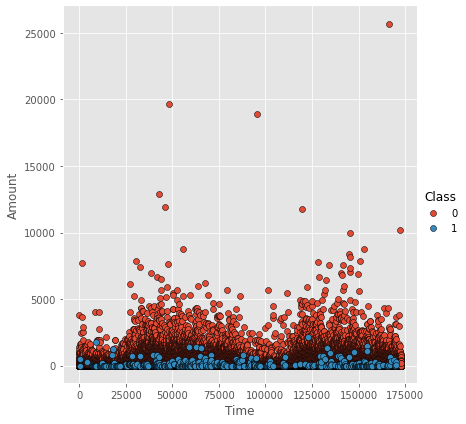

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")
sns.FacetGrid(data, hue="Class", size = 6).map(plt.scatter, "Time", "Amount", edgecolor="k").add_legend()
plt.show()

The above plot shows that there are frauds only on the transactions which have transaction amount less than 2500 (approx). However, the frauds in the transactions are evenly distributed throughout all times.

# 1. Finding Similarity in Transactions:

Let us work with **Cosine Similarity** metric. The definition goes like: $similarity_{(i,j)}$ = dot product ($v_{i}$, $v_{j}$) / length($v_{i}$) * length($v_{j}$). We took out a big chunk of sample from the data set which contains 284800 transactions. Now, for rest 6 transactions in the data set, every transaction is matched with the sample to find out top 5 transactions having the highest $similarity_{(i,j)}$.

In [6]:
from scipy import spatial
sample_data = data.head(284800) 
samples = data.loc[284801:284807]

In [7]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return False;
}

<IPython.core.display.Javascript object>

In [8]:
frame = []
for i in range(284801, 284807): 
    t1 = samples.loc[i]
    cls = samples.loc[i]["Class"]
    for j in range(284800):
        t2 = sample_data.loc[j]
        class_label = data.loc[j]["Class"]
        similarity = 1 - spatial.distance.cosine(t1, t2)
        if (class_label == 1):
            frame.append([class_label, similarity, j])
        
    df = pd.DataFrame(frame, columns=['Class', 'Similarity', 'Transaction ID'])
    df_sorted = df.sort_values("Similarity", ascending=False)
    print("Top 5 suspected-fraud transactions having highest similarity with transaction ID = "+str(i)+ ":")
    print(df_sorted.iloc[:5])
    print("\n")
    frame = []

Top 5 suspected-fraud transactions having highest similarity with transaction ID = 284801:
     Class  Similarity  Transaction ID
404    1.0         1.0          219025
476    1.0         1.0          263080
447    1.0         1.0          245347
399    1.0         1.0          214775
410    1.0         1.0          222419


Top 5 suspected-fraud transactions having highest similarity with transaction ID = 284802:
     Class  Similarity  Transaction ID
399    1.0         1.0          214775
404    1.0         1.0          219025
476    1.0         1.0          263080
452    1.0         1.0          248971
410    1.0         1.0          222419


Top 5 suspected-fraud transactions having highest similarity with transaction ID = 284803:
     Class  Similarity  Transaction ID
485    1.0         1.0          276071
434    1.0         1.0          238466
396    1.0         1.0          213092
194    1.0         1.0           79874
157    1.0         1.0           57248


Top 5 suspected-fra

# 2A. Visualizing Frauds in 3D with PCA

PCA (Principal Component Analysis) is an unsupervised ***linear*** dimensionality reduction technique. It tries to preserve the ***global structure*** of data. PCA is a ***deterministic*** method. We will reduce our entire data set into three principal components and then we will plot the figure to visualize anomalies. The red cross points are outliers and the green points are inliers.

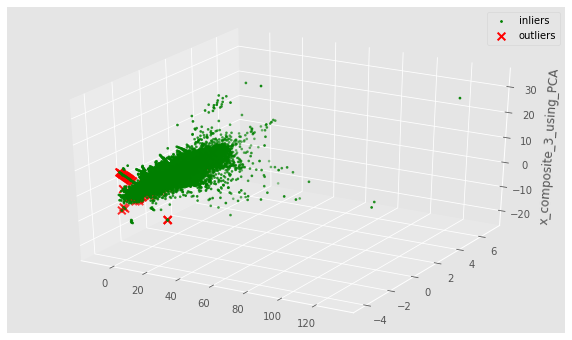

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)  #Considered only 3 components to put into 3 dimensions
to_model_cols = data.columns[0:30]
outliers = data.loc[data['Class']==1]
outlier_index=list(outliers.index)
scaler = StandardScaler()
X = scaler.fit_transform(data[to_model_cols])
X_reduce = pca.fit_transform(X)
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_zlabel("x_composite_3_using_PCA")
# Plotting compressed data points
ax.scatter(X_reduce[:, 0], X_reduce[:, 1], zs=X_reduce[:, 2], s=3, lw=1, label="inliers",c="green")
# Plot x for the ground truth outliers
ax.scatter(X_reduce[outlier_index,0],X_reduce[outlier_index,1], X_reduce[outlier_index,2],
           s=60, lw=2, marker="x", c="red", label="outliers")
ax.legend()
plt.show()

# 2B. Visualizing Frauds in 3D using t-SNE

t-SNE (t-distributed Stochastic Neighbourhood Embedding) is an unsupervised ***non-linear*** dimensionality reduction technique. It tries to preserve the ***local structure*** of data. We will reduce our entire data set into three t-SNE components and then we will plot the figure to visualize anomalies. Unlike PCA, it is a ***non-deterministic*** or ***probabilistic*** method. In simple heuristic terms, we can say that PCA preserves large distances between data points, whereas t-SNE preserves data points which are close to each other. Here, for avoiding long time for execution, we have used a small chunk of data with 50000 transaction records from the original data set.

In [10]:
from sklearn.manifold import TSNE
standardized_data = StandardScaler().fit_transform(data)
data_50k = standardized_data[0:50000]
tsne = TSNE(n_components=3, verbose=1, perplexity=40, n_iter=250)
data_50k_reduced = tsne.fit_transform(data_50k)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.264s...
[t-SNE] Computed neighbors for 50000 samples in 149.352s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for 

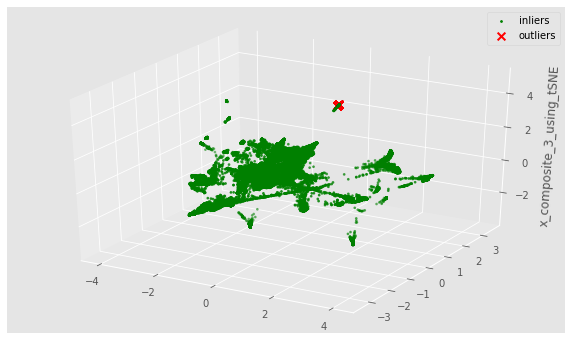

In [11]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.set_zlabel("x_composite_3_using_tSNE")
# Plotting the compressed data points
ax.scatter(data_50k_reduced[:, 0], data_50k_reduced[:, 1], zs=data_50k_reduced[:, 2], s=3, lw=1, label="inliers",c="green")
# Plot x(s) for the ground truth outliers
out_index = [i for i in outlier_index if i <= 50000]
ax.scatter(data_50k_reduced[out_index,0],data_50k_reduced[out_index,1], data_50k_reduced[out_index,2], lw=2, s=60, 
           marker="x", c="red", label="outliers")
ax.legend()
plt.show()

We can observe how the shape is different here as compared to what we got previously using PCA. Here, even though the inliers are scattered in different directions, there are inter-connectivities among them. It is evident that outliers are ***more appropriately*** detected here considering all non-linear inter-relationships among the features.

# 3A. Algorithm-1A: Isolation Forest in Unsupervised Sense:

Isolation Forest algorithm isolates anomalous points from the rest of the sample (normal points) by recursively generating partitions on the sample by randomly selecting an attribute and then randomly selecting a split value for the attribute. As the term "forest" suggests, this algorithm has a decision tree approach. Here, we will use Isolation Forest algorithm in truly unsupervised sense i.e. ***we will not use the labels***. 

In [12]:
from sklearn.ensemble import IsolationForest
datacopy = data.copy()
datacopy.columns
to_model_cols = datacopy.columns[0:30]
clf = IsolationForest(n_estimators=10, max_samples='auto', contamination=float(.0009), 
                      max_features=1.0, bootstrap=False, n_jobs=-1, random_state=12345, verbose=0)
clf.fit(datacopy[to_model_cols])
pred = clf.predict(datacopy[to_model_cols])
datacopy['Class'] = pred
outliers = datacopy.loc[datacopy['Class']==-1]
outlier_index=list(outliers.index)
#Find the number of anomalies and normal points (points classified as "-1" are anomalous)
print(datacopy['Class'].value_counts())

 1    284565
-1       242
Name: Class, dtype: int64


We can observe unsupervised IForest could detect 242 anomalous points here. Originally we have 492 fraud labels.

# 3B. Algorithm-1B: Isolation Forest in Supervised Sense:

Well, since the labels are given in the data set, why not try using them to find the model performance? So, here we will try using Isolation Forest algorithm with a flavour of supervised learning ***(using labels)***. However, one thing to keep in mind is that, all the anomaly detection algorithms are inherently meant for using in unsupervised sense.

In [13]:
from sklearn.metrics import accuracy_score, classification_report
n_outliers = len(data[data['Class']==1])
outlier_fraction = len(data[data['Class']==1])/float(len(data[data['Class']==0]))
clf = IsolationForest(n_estimators=100, max_samples=len(data.loc[:,data.columns!='Class']), 
                      contamination=outlier_fraction, random_state=12345, verbose=0)
X = data.loc[:,data.columns!='Class']
Y = data['Class']
clf.fit(X)
scores_prediction = clf.decision_function(X)
y_pred = clf.predict(X)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
n_errors = (y_pred != Y).sum()

print("{}: {}".format("No. of Anomalous Points with Isolation Forest ",n_errors))
print("Accuracy Score :",accuracy_score(Y,y_pred))
print("Classification Report :")
print(classification_report(Y,y_pred))

No. of Anomalous Points with Isolation Forest : 661
Accuracy Score : 0.9976791300775613
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.33      0.33      0.33       492

    accuracy                           1.00    284807
   macro avg       0.66      0.66      0.66    284807
weighted avg       1.00      1.00      1.00    284807



We have got 661 anomalous points with 99.76% accuracy.

# 4A. Algorithm-2A: Local Outlier Factor in Unsupervised Sense 

Local Outlier Factor (LOF) finds anomalous data points by measuring the local deviation of a given data point with respect to its neighbouring data points. It has a working principle similar to density based clustering algorithms like DBSCAN etc. Here, I have used it in purely unsupervised sense first ***(without using labels)***. Here also, I used a smaller sample of data to avoid longer execution-time.

In [14]:
from sklearn.neighbors import LocalOutlierFactor
clf_lof = LocalOutlierFactor(n_neighbors=30, algorithm='auto', contamination=.1)
standardized_data_without_class = StandardScaler().fit_transform(data.loc[:,data.columns!='Class'])
data_50k_new = standardized_data_without_class[0:50000]
data_50k_df = pd.DataFrame(data=data_50k_new)
y_pred = clf_lof.fit_predict(data_50k_df)
LOF_Scores = clf_lof.negative_outlier_factor_
LOF_pred=pd.Series(y_pred).replace([-1,1],[1,0])
LOF_anomalies=data_50k_df[LOF_pred==1]

In [15]:
# Check if all scores are negative
LOF_Scores

array([-1.06437549, -1.0786067 , -1.25629538, ..., -1.11123033,
       -1.01999028, -1.09610749])

Now, we will visualize samples of feature-pair-wise scatter plots. For convenience, I have just drawn 5 consecutive pairs.

In [16]:
import numpy as np
cmap=np.array(["skyblue","red"])
def plot_lof(i):
    plt.scatter(data_50k_df.iloc[:,i],data_50k_df.iloc[:,i+1],c="skyblue",s=40, edgecolor="k")
    plt.scatter(LOF_anomalies.iloc[:,i],LOF_anomalies.iloc[:,i+1],c="red", s=40, edgecolor="k")
    plt.title("Visualize Local Outlier Factors between Feature Pair: V{} and V{}".format(i,i+1))
    plt.xlabel("V{}".format(i))
    plt.ylabel("V{}".format(i+1))

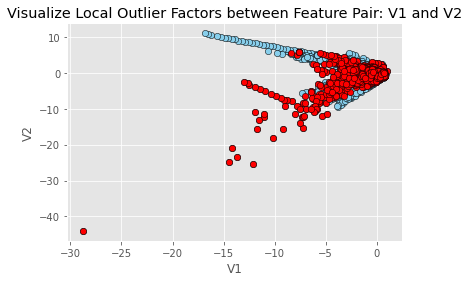

In [17]:
plot_lof(1)

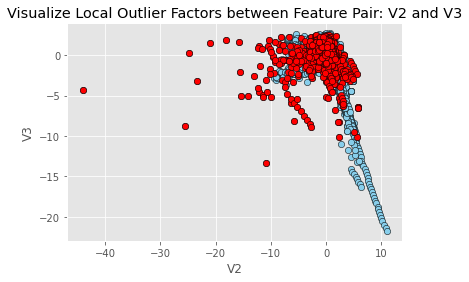

In [18]:
plot_lof(2)

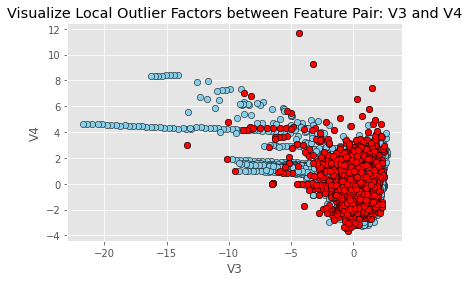

In [19]:
plot_lof(3)

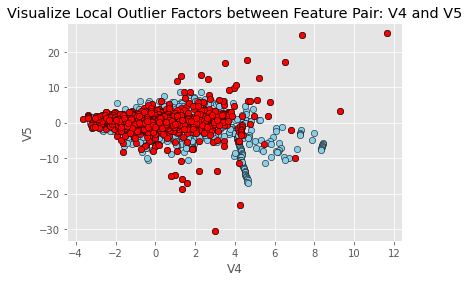

In [20]:
plot_lof(4)

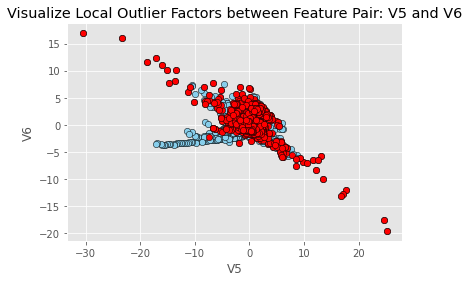

In [21]:
plot_lof(5)

# 4B. Algorithm-2B: Local Outlier Factor using Supervised Learning

As we did earlier, here also, we will use LOF with a flavour of supervised learning ***using explicitly the "Class" labels***.

In [22]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, classification_report
n_outliers = len(data[data['Class']==1])
outlier_fraction = len(data[data['Class']==1])/float(len(data[data['Class']==0]))
clflof = LocalOutlierFactor(n_neighbors=30, algorithm='auto', contamination=outlier_fraction)
X = data.loc[:,data.columns!='Class']
Y = data['Class']
y_pred = clflof.fit_predict(X)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
n_errors = (y_pred != Y).sum()
print("{}: {}".format("No. of Anomalous Points with Local Outlier Factors ",n_errors))
print("Accuracy Score :")
print(accuracy_score(Y,y_pred))
print("Classification Report :")
print(classification_report(Y,y_pred))

No. of Anomalous Points with Local Outlier Factors : 949
Accuracy Score :
0.9966679189767106
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.04      0.04      0.04       492

    accuracy                           1.00    284807
   macro avg       0.52      0.52      0.52    284807
weighted avg       1.00      1.00      1.00    284807



It has predicted 949 anomalies with 99.67% accuracy.

# 5A. Algorithm-3A: Elliptic Envelope using Unsupervised Learning

Elliptic Envelope (EE) is used for fitting a multivariate Gaussian with a robust covariance estimate. EE fits data into the tightest Gaussian (smallest volume ellipsoid) discarding some fixed fraction of contamination points set by the user. Here, we have used in in purely unsupervised sense ***without using "Class" labels***.

In [23]:
import warnings
warnings.filterwarnings('ignore')

In [24]:
from sklearn.covariance import EllipticEnvelope

clf_ee = EllipticEnvelope(assume_centered=False, contamination=0.1, random_state=12345, store_precision=True, 
                          support_fraction=0.7)
y_predict = clf_ee.fit_predict(data_50k_df)
ee_predict = pd.Series(y_predict).replace([-1,1],[1,0])
ee_anomalies = data_50k_df[ee_predict==1]

In [25]:
cmap=np.array(['skyblue','red'])
def plot_EE(i):
    plt.scatter(data_50k_df.iloc[:,i],data_50k_df.iloc[:,i+1],c='skyblue',s=40, edgecolor="k")
    plt.scatter(ee_anomalies.iloc[:,i],ee_anomalies.iloc[:,i+1],c='red', s=40, edgecolor="k")
    plt.title("Visualize Elliptic Envelope Anomalies between Feature Pair: V{} and V{}".format(i,i+1))
    plt.xlabel("V{}".format(i))
    plt.ylabel("V{}".format(i+1))

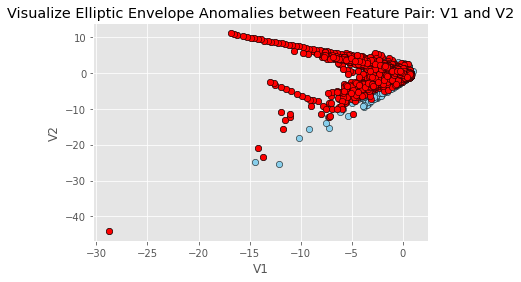

In [26]:
plot_EE(1)

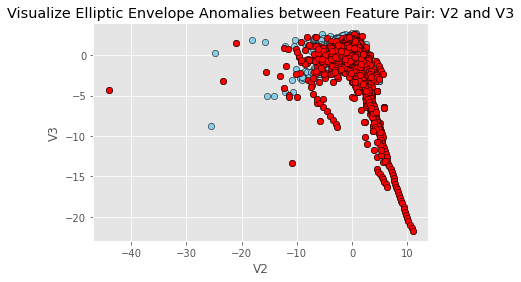

In [27]:
plot_EE(2)

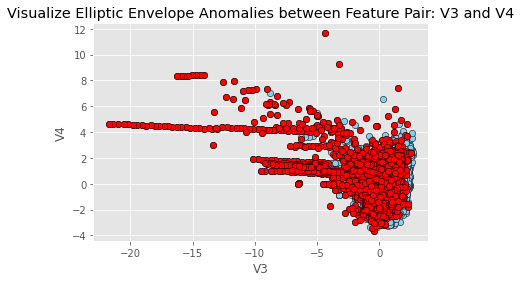

In [28]:
plot_EE(3)

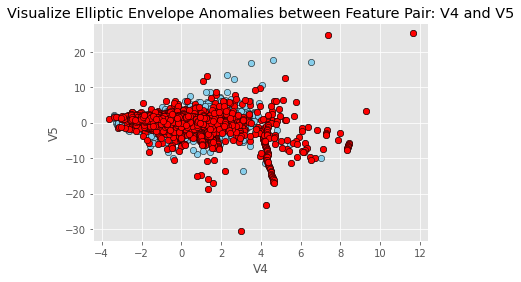

In [29]:
plot_EE(4)

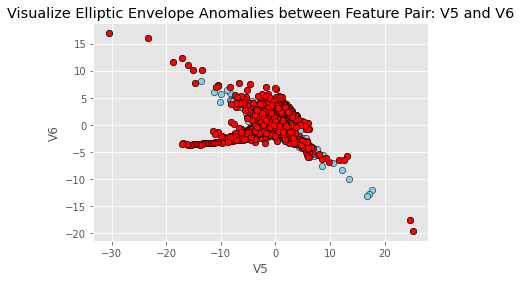

In [30]:
plot_EE(5)

Spot the difference! How these visuals with EE are different from what we had got earlier with LOF.

# 5B. Algorithm-3B: Elliptic Envelope using Supervised Learning

On the same line, we will use EE in a supervised sense ***using labels.***

In [31]:
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import accuracy_score, classification_report
n_outliers = len(data[data['Class']==1])
outlier_fraction = len(data[data['Class']==1])/float(len(data[data['Class']==0]))
clfee = EllipticEnvelope(assume_centered=False, contamination=outlier_fraction, random_state=12345, 
                         store_precision=True, support_fraction=0.7)
X = data.loc[:,data.columns!='Class']
Y = data['Class']
y_pred = clfee.fit_predict(X)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
n_errors = (y_pred != Y).sum()
print("{}: {}".format("No. of Anomalous Points with Elliptic Envelope ",n_errors))
print("Accuracy Score :")
print(accuracy_score(Y,y_pred))
print("Classification Report :")
print(classification_report(Y,y_pred))

No. of Anomalous Points with Elliptic Envelope : 769
Accuracy Score :
0.9972999259147423
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.22      0.22      0.22       492

    accuracy                           1.00    284807
   macro avg       0.61      0.61      0.61    284807
weighted avg       1.00      1.00      1.00    284807



Supervised EE has predicted 799 frauds with 99.72% accuracy.

# 6A. Algorithm-4A: One-Class SVM in Unsupervised Sense

One-Class SVM is supposed to apply on a data set having a single class with a very few number of anomalies. It is an unsupervised algorithm that learns a decision function for ***novelty detection***. One-Class SVM works almost identically as SVM, but instead of using a hyperplane to separate two classes of data points, it uses a hypersphere to encompass all of the data points.  Here again we ***will not use labels*** first.

In [32]:
from sklearn import svm
clf_svm = svm.OneClassSVM(kernel="rbf", degree=3, gamma=0.1, nu=0.01, max_iter=-1)
y_predict = clf_svm.fit_predict(data_50k_df)
svm_predict = pd.Series(y_predict).replace([-1,1],[1,0])
svm_anomalies = data_50k_df[svm_predict==1]

In [33]:
cmap=np.array(['skyblue','red'])
def plot_OCSVM(i):
    plt.scatter(data_50k_df.iloc[:,i],data_50k_df.iloc[:,i+1],c='skyblue',s=40, edgecolor="k")
    plt.scatter(svm_anomalies.iloc[:,i],svm_anomalies.iloc[:,i+1],c='red', s=40, edgecolor="k")
    plt.title("Visualize OC-SVM Anomalies between Feature Pair: V{} and V{}".format(i,i+1))
    plt.xlabel("V{}".format(i))
    plt.ylabel("V{}".format(i+1))

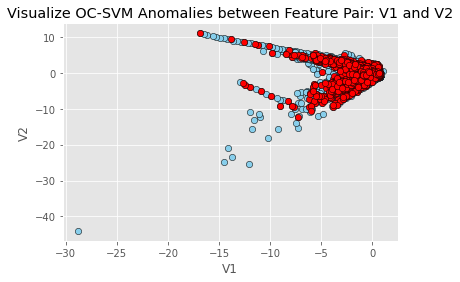

In [34]:
plot_OCSVM(1)

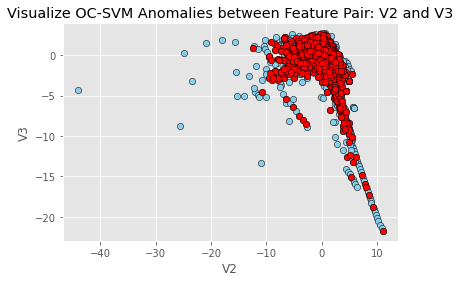

In [35]:
plot_OCSVM(2)

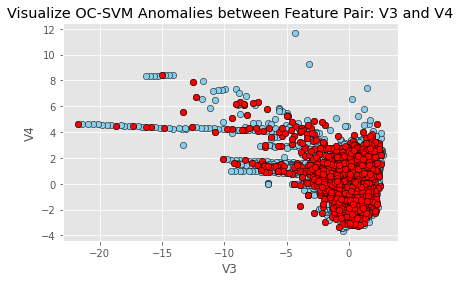

In [36]:
plot_OCSVM(3)

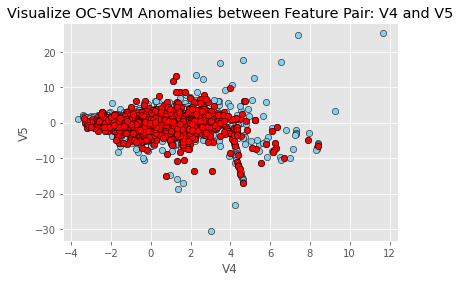

In [37]:
plot_OCSVM(4)

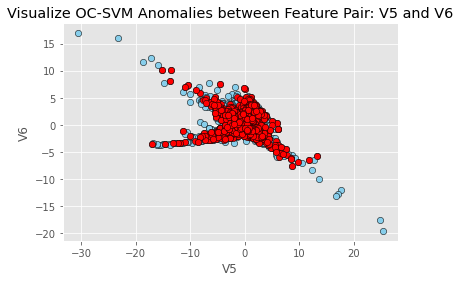

In [38]:
plot_OCSVM(5)

Interestingly, we spot very rare number of skyblue points here. No doubt, One-Class SVM works very well to detect rare events!

# 6B. Algorithm-4B: One-Class SVM in Supervised Sense

Again we will ***use the labels*** and experiment.

In [39]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, classification_report
outlier_fraction = len(data[data['Class']==1])/float(len(data[data['Class']==0]))
clfsvm = OneClassSVM(kernel="rbf", nu=outlier_fraction)
X = data.loc[:,data.columns!='Class']
Y = data['Class']
y_pred = clfsvm.fit_predict(X)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1
n_errors = (y_pred != Y).sum()
print("{}: {}".format("No. of Anomalous Points with One-Class SVM ",n_errors))
print("Accuracy Score :")
print(accuracy_score(Y,y_pred))
print("Classification Report :")
print(classification_report(Y,y_pred))

No. of Anomalous Points with One-Class SVM : 985
Accuracy Score :
0.9965415175891043
Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.00      0.00      0.00       492

    accuracy                           1.00    284807
   macro avg       0.50      0.50      0.50    284807
weighted avg       1.00      1.00      1.00    284807



Supervised OCSVM has predicted 985 anomalies with 99.65% accuracy.

# 7. Self-Organized Maps to Detect Frauds:

Self-Organizing Map (SOM) is a neural model that is trained using ***unsupervised learning*** to produce a low-dimensional (typically 2D), discretized map. It is a powerful visual tool from which one can easily detect rare events like frauds.

In [40]:
!pip install minisom

  Created wheel for minisom: filename=MiniSom-2.3.0-py3-none-any.whl size=9018 sha256=e082e3d62f376f085bdee5b944592d9f3130c00da3f1ed9fe50dc2564cdd81fe
  Stored in directory: /root/.cache/pip/wheels/d4/ca/4a/488772b0399fec45ff53132ed14c948dec4b30deee3a532f80
Successfully built minisom
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [41]:
from sklearn.preprocessing import MinMaxScaler
from minisom import MiniSom

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
mm = MinMaxScaler(feature_range = (0, 1))
X = mm.fit_transform(X)
som = MiniSom(x = 10, y = 10, input_len = 30, sigma = 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

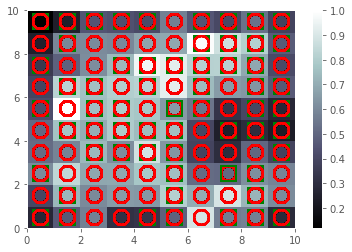

In [42]:
from pylab import bone, pcolor, colorbar, plot, show

bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']

for i, x in enumerate(X):
    w = som.winner(x)
    plot(w[0]+0.5, w[1]+0.5, markers[y[i]], markeredgecolor = colors[y[i]],
    markerfacecolor = 'None', markersize = 15, markeredgewidth = 2)

show()

The points which have red circles encircled within green squares have anomalies. Most importantly, the red circles which are falling in pure white squares have the highest possibility of fraud. In above SOM, we can observe square (5,9) and (2,6) are fully white. So, they have the highest possibility of fraud.

**Note:** **SOM might produce a different map in the next run. So there is a possibility that after my final submission, you might get to see the white square in a different position altogether.**

In [43]:
# Mapping the winning node
mappings = som.win_map(X)
# Finding frauds
import numpy as np
frauds = np.concatenate((mappings[(5, 9)], mappings[(2,6)]), axis = 0)
frauds = mm.inverse_transform(frauds)

Now, we can extract the list of fraudulent records.

In [44]:
# Print the list of frauds
frauds

array([[ 4.47250000e+04, -1.15950963e+01,  5.32933603e+00, ...,
         4.93250840e-01, -4.32377069e-01,  4.65200000e+01],
       [ 5.05630000e+04, -1.21567747e+01,  5.76772562e+00, ...,
         4.27407040e-01, -4.46474294e-01,  3.10400000e+01],
       [ 6.03560000e+04, -9.87047836e+00,  6.49412006e+00, ...,
         2.02806887e+00,  1.54432120e+00,  3.00000000e+01],
       ...,
       [ 1.64814000e+05,  2.18225613e+00, -9.94340420e-01, ...,
        -2.31887325e-02, -6.75247544e-02,  2.50000000e+01],
       [ 1.66279000e+05,  2.17188565e+00, -8.50235745e-01, ...,
        -2.56586603e-02, -5.14904599e-02,  2.49500000e+01],
       [ 1.67208000e+05,  2.26720115e+00, -7.03079557e-01, ...,
        -4.98335522e-02, -6.26226333e-02,  4.13000000e+00]])